# 04 Modeling Checkpoint
# This notebook validates the machine learning workflow
# using a public transport delay dataset before applying
# the pipeline to the Auckland GTFS + Open-Meteo dataset.

In [76]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [77]:
#load dataset
PROJECT_ROOT = Path.cwd().parent

dataset_path = PROJECT_ROOT / "data" / "raw" / "modeling" / "public_transport_delays.csv"

df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 24)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,None,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,None,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,None,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,None,500,46,0,0,6,Spring,1


In [78]:
#inpect dataset
print(df.columns.tolist())

['trip_id', 'date', 'time', 'transport_type', 'route_id', 'origin_station', 'destination_station', 'scheduled_departure', 'scheduled_arrival', 'actual_departure_delay_min', 'actual_arrival_delay_min', 'weather_condition', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'season', 'delayed']


In [79]:
#check for missing values
df.isna().sum()

trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64

In [80]:
#Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [81]:
# Target variable inspection

target_col = "delayed"

print("Target distribution:")
print(df[target_col].value_counts())

print("\nTarget percentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Target distribution:
1    1499
0     501
Name: delayed, dtype: int64

Target percentage:
1    74.95
0    25.05
Name: delayed, dtype: float64


In [82]:
# Basic delay statistics

delay_cols = [
    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

df[delay_cols].describe()

,actual_departure_delay_min,actual_arrival_delay_min
count,2000.000000,2000.000000
mean,8.688000,13.318000
std,6.268118,9.289727
min,-2.000000,-3.000000
25%,3.000000,5.000000
50%,9.000000,13.000000
75%,14.000000,21.000000
max,19.000000,29.000000


# Feature Selection and Data Leakage Prevention

This step removes columns that directly reveal delay outcomes,
preventing data leakage during model training.

In [83]:
# Feature selection

# Columns to remove (data leakage + identifiers)
drop_columns = [
    "trip_id",
    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

# Create modeling dataframe
model_df = df.drop(columns=drop_columns)

print("Remaining columns:")
print(model_df.columns.tolist())

print("\nShape after feature selection:")
print(model_df.shape)

Remaining columns:
['date', 'time', 'transport_type', 'route_id', 'origin_station', 'destination_station', 'scheduled_departure', 'scheduled_arrival', 'weather_condition', 'temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'season', 'delayed']

Shape after feature selection:
(2000, 21)


# Encoding Categorical Features

Machine learning models require numerical inputs.
Categorical transport and weather variables are encoded into numeric representations.

In [84]:
# Encode categorical variables

categorical_columns = [
    "transport_type",
    "route_id",
    "origin_station",
    "destination_station",
    "weather_condition",
    "event_type",
    "season"
]

model_df_encoded = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded dataset shape:")
print(model_df_encoded.shape)

model_df_encoded.head()

Encoded dataset shape:
(2000, 147)


,date,time,scheduled_departure,scheduled_arrival,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,...,weather_condition_Snow,weather_condition_Storm,event_type_Festival,event_type_None,event_type_Parade,event_type_Protest,event_type_Sports,season_Spring,season_Summer,season_Winter
0,2023-01-01,05:00:00,05:02:00,05:55:00,5.1,52,46,13.0,500,81,...,0,1,0,1,0,0,0,0,0,1
1,2023-01-01,05:15:00,05:16:00,05:55:00,34.0,64,11,11.4,0,53,...,0,0,0,1,0,0,0,0,0,0
2,2023-01-01,05:30:00,05:33:00,06:17:00,29.5,35,31,14.1,0,67,...,0,0,0,0,0,0,1,0,0,0
3,2023-01-01,05:45:00,05:49:00,06:08:00,27.4,55,41,6.4,500,84,...,0,0,0,1,0,0,0,0,0,1
4,2023-01-01,06:00:00,06:00:00,06:35:00,0.1,90,30,18.5,500,46,...,1,0,0,1,0,0,0,1,0,0


# Time Feature Engineering

Date and time columns are converted into numeric features so they can be used by machine learning models.

In [85]:
# Time feature engineering

model_df_encoded["date"] = pd.to_datetime(model_df_encoded["date"])

model_df_encoded["trip_hour"] = pd.to_datetime(
    model_df_encoded["time"],
    format="%H:%M:%S"
).dt.hour

model_df_encoded["scheduled_departure_hour"] = pd.to_datetime(
    model_df_encoded["scheduled_departure"],
    format="%H:%M:%S"
).dt.hour

model_df_encoded["scheduled_arrival_hour"] = pd.to_datetime(
    model_df_encoded["scheduled_arrival"],
    format="%H:%M:%S"
).dt.hour

model_df_encoded["day_of_month"] = model_df_encoded["date"].dt.day
model_df_encoded["month"] = model_df_encoded["date"].dt.month

# Drop original raw date/time string columns after feature extraction
model_df_encoded = model_df_encoded.drop(
    columns=[
        "date",
        "time",
        "scheduled_departure",
        "scheduled_arrival"
    ]
)

print("Shape after time feature engineering:")
print(model_df_encoded.shape)

print("\nRemaining non-numeric columns:")
print(model_df_encoded.select_dtypes(include=["object"]).columns.tolist())

model_df_encoded.head()

Shape after time feature engineering:
(2000, 148)

Remaining non-numeric columns:
[]


,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed,...,event_type_Protest,event_type_Sports,season_Spring,season_Summer,season_Winter,trip_hour,scheduled_departure_hour,scheduled_arrival_hour,day_of_month,month
0,5.1,52,46,13.0,500,81,0,1,6,0,...,0,0,0,0,1,5,5,5,1,1
1,34.0,64,11,11.4,0,53,0,0,6,1,...,0,0,0,0,0,5,5,5,1,1
2,29.5,35,31,14.1,0,67,1,0,6,0,...,0,1,0,0,0,5,5,6,1,1
3,27.4,55,41,6.4,500,84,0,0,6,1,...,0,0,0,0,1,5,5,6,1,1
4,0.1,90,30,18.5,500,46,0,0,6,1,...,0,0,1,0,0,6,6,6,1,1


# Train-Test Split

The dataset is divided into training and testing subsets
to evaluate model generalization on unseen data.

In [86]:
# Train-test split

from sklearn.model_selection import train_test_split

# Target variable
y = model_df_encoded["delayed"]

# Feature matrix
X = model_df_encoded.drop(columns=["delayed"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Feature matrix shape: (2000, 147)
Target shape: (2000,)

Training set shape: (1600, 147)
Testing set shape: (400, 147)

Training target distribution:
1    74.9375
0    25.0625
Name: delayed, dtype: float64

Testing target distribution:
1    75.0
0    25.0
Name: delayed, dtype: float64


# XGBoost Baseline Model

In [87]:
# XGBoost baseline classifier

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Accuracy:", round(accuracy * 100, 2), "%")

# Classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

XGBoost Accuracy: 73.25 %

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.03      0.05       100
           1       0.75      0.97      0.84       300

    accuracy                           0.73       400
   macro avg       0.49      0.50      0.45       400
weighted avg       0.62      0.73      0.65       400


Confusion Matrix:
[[  3  97]
 [ 10 290]]


# Balanced XGBoost Model

The first XGBoost model favored the majority delayed class.  
This section applies class weighting so the model pays more attention to the minority non-delayed class.

In [88]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate imbalance ratio
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class count:", negative_count)
print("Positive class count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

# Initialize balanced model
xgb_balanced_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# Train model
xgb_balanced_model.fit(X_train, y_train)

# Predict
y_pred_balanced = xgb_balanced_model.predict(X_test)

# Evaluate
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced XGBoost Accuracy:", round(balanced_accuracy * 100, 2), "%")

print("\nBalanced Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nBalanced Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Negative class count: 401
Positive class count: 1199
scale_pos_weight: 0.33444537114261885
Balanced XGBoost Accuracy: 61.0 %

Balanced Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.23      0.23       100
           1       0.74      0.74      0.74       300

    accuracy                           0.61       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.61      0.61      0.61       400


Balanced Confusion Matrix:
[[ 23  77]
 [ 79 221]]


# ARIMA Baseline Model

This section establishes a traditional time-series forecasting baseline
for comparison against the XGBoost machine learning model.

In [89]:
# ARIMA baseline model

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# Use delay variable only
delay_series = df["actual_arrival_delay_min"]

# Train-test split for time series
train_size = int(len(delay_series) * 0.8)

train_series = delay_series[:train_size]
test_series = delay_series[train_size:]

print("Train series size:", len(train_series))
print("Test series size:", len(test_series))

# Build ARIMA model
arima_model = ARIMA(train_series, order=(2,1,2))

arima_result = arima_model.fit()

# Forecast
forecast = arima_result.forecast(steps=len(test_series))

# Evaluate
mae = mean_absolute_error(test_series, forecast)

print("ARIMA Mean Absolute Error (MAE):", round(mae, 2))

# Preview predictions
comparison_df = pd.DataFrame({
    "Actual": test_series.values[:10],
    "Forecast": np.round(forecast.values[:10], 2)
})

comparison_df

Train series size: 1600
Test series size: 400
ARIMA Mean Absolute Error (MAE): 8.16


,Actual,Forecast
0,11,13.11
1,23,12.91
2,27,13.21
3,4,12.91
4,26,13.21
5,14,12.91
6,0,13.21
7,18,12.92
8,-1,13.20
9,11,12.92


# SHAP Explainability Analysis

This section analyzes feature importance and interprets
the factors influencing transport delay predictions
using SHAP explainability techniques.

In [91]:
# SHAP explainability

import shap
import numpy as np

# Create explainer using the balanced XGBoost model
explainer = shap.TreeExplainer(xgb_balanced_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")
print("SHAP shape:", np.array(shap_values).shape)

SHAP values generated successfully.
SHAP shape: (400, 147)


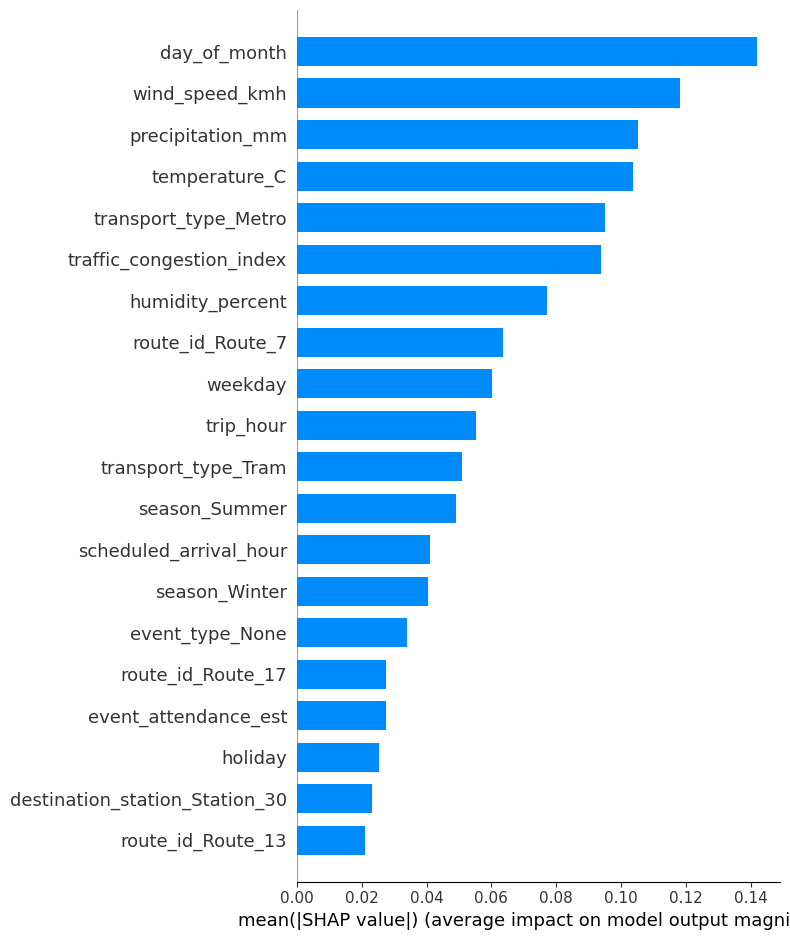

In [92]:
# SHAP summary bar plot

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

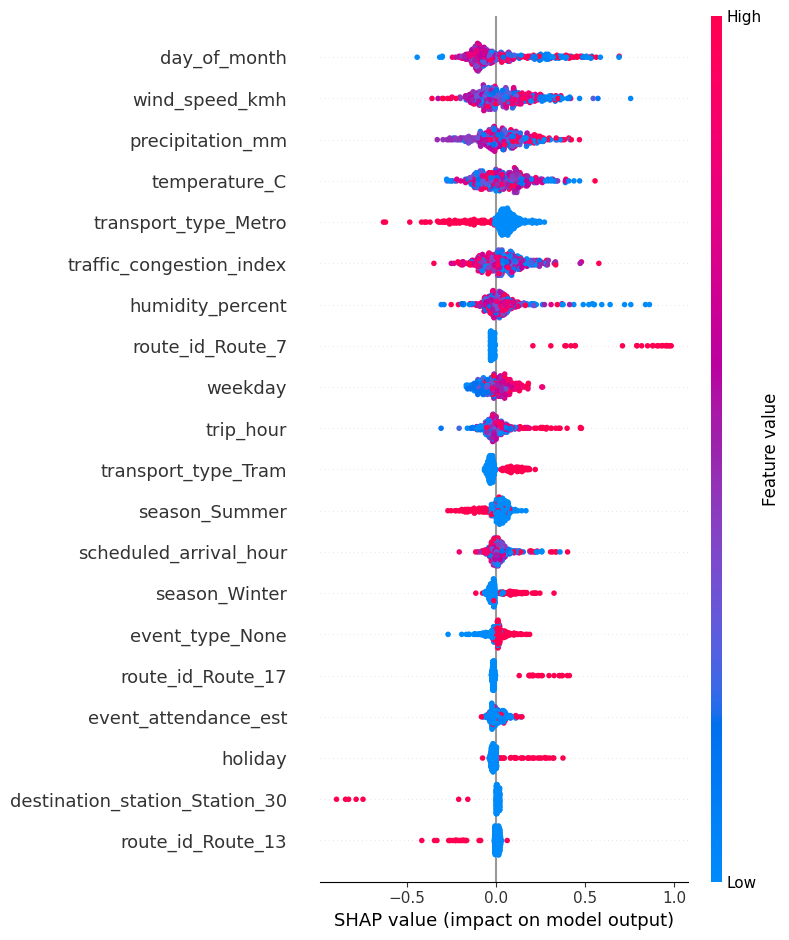

In [93]:
# Detailed SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test
)